<a href="https://www.kaggle.com/code/lalit7881/indian-packaged-foods-nutritional-eda-85?scriptVersionId=337561315" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import warnings 
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/lalit7881/indian-packaged-foods-nutritional-dataset-2026/packaged_foods_india.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/lalit7881/indian-packaged-foods-nutritional-dataset-2026/packaged_foods_india.csv")

In [3]:
df.head()

,S.No,Item name,Brand_Name,Category,Sub_Category,Ingredients,Serving_Size_g,Calories_kcal,Carbohydrates_g,Proteins_g,...,Dietary_Fiber_g,Cholesterol_mg,Calcium_mg,Vitamin,Iron_mg,Price_INR,Source_of_Data,Collection_Date,Collected_By,Remarks
0,1,HIDE & SEEK®,PARLE,BISCUIT,COOKIES,"REFINED WHEAT FLOUR (MAIDA), CHOCOLATE (23%) ...",100.0,479.0,73.4,5.9,...,0,0,0.0,0,0.0,30.0,ZEPTO,23-10-2025,NaN,NaN
1,2,Britannia Nutrichoice Digestive High-Fibre Bis...,BRITANNIA,BISCUIT,DIGESTIVE BISCUIT,"WHEAT FLOUR (ATTA) (65.5%), REFINED PALM OIL, ...",100.0,483.0,68.0,9.3,...,6.7,0.1,0.0,0,0.0,20.0,NaN,NaN,NaN,NaN
2,3,"Sunfeast Dark Fantasy Choco Fills, Original Fi...",SUNFEAST,BISCUIT,CHOCO FILLS,"SUGAR, REFINED PALMOLEIN, REFINED PALM OIL, C...",100.0,507.0,61.1,7.3,...,0,0.3,0.0,0,0.0,170.0,NaN,NaN,NaN,NaN
3,4,Sunfeast Baked Creations Rich Choco Chip Cookies,SUNFEAST,BISCUIT,COOKIES,"MAIDA (REFINED WHEAT FLOUR), DARK CHOCOLATE CH...",20.0,105.0,12.6,1.2,...,0,1,0.0,0,0.0,25.0,NaN,NaN,NaN,NaN
4,5,"sunfeast Dark Fantasy Bourbon, Classic Biscuit...",SUNFEAST,BISCUIT,CREAME,"Cocoa Solids (2.3%), Emulsifiers lecithin (fro...",108.0,445.0,77.4,9.1,...,0,0.1,0.0,"Vitamin B1 (mg) 0.3, Vitamin B2 (mg0 0.3, Vita...",2.9,35.0,NaN,NaN,NaN,NaN


In [4]:
df.tail()

,S.No,Item name,Brand_Name,Category,Sub_Category,Ingredients,Serving_Size_g,Calories_kcal,Carbohydrates_g,Proteins_g,...,Dietary_Fiber_g,Cholesterol_mg,Calcium_mg,Vitamin,Iron_mg,Price_INR,Source_of_Data,Collection_Date,Collected_By,Remarks
847,848,Dairy Day Nutty Ice Cream Stick,DAIRY DAY,ICEREAMES,STICK,Outer Layer: Choco Compound Coating (25%) (Sug...,65.0,175.65,15.32,2.47,...,0,14,0.0,0,0.0,25.0,NaN,NaN,NaN,NaN
848,849,Grameen Dry Fruit Matka Kulfi Ice Cream Cup,GRAMEEN,ICEREAMES,KULFI,"Milk, Sugar, Pistachio, Almond, Cashew, and Pe...",100.0,240.91,26.01,7.21,...,0,0,0.0,0,0.0,190.0,NaN,NaN,NaN,NaN
849,850,Grameen Kesar Pista Kulfi Ice Cream Stick,GRAMEEN,ICEREAMES,KULFI,"Milk, Sugar, Pistachio and Saffron",70.0,154.00,16.10,4.1,...,5.7,21.3,0.0,0,0.0,75.0,NaN,NaN,NaN,NaN
850,851,Grameen Desi Malai Kulfi Ice Cream Stick,GRAMEEN,ICEREAMES,KULFI,"Milk,Sugar",70.0,155.00,18.30,4.5,...,0,10.1,0.0,0,0.0,70.0,NaN,NaN,NaN,NaN
851,852,Kwality Walls Cassata,KWALITY WALLS CADBUARY,ICEREAMES,CASSATA,"Water, Cake (16%) (Water, Refined Wheat Flour ...",65.0,157.00,19.70,3.5,...,0,0,0.0,0,0.0,70.0,NaN,NaN,NaN,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 852 entries, 0 to 851
Data columns (total 25 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   S.No             852 non-null    int64  
 1   Item name        852 non-null    object 
 2   Brand_Name       852 non-null    object 
 3   Category         852 non-null    object 
 4   Sub_Category     852 non-null    object 
 5   Ingredients      852 non-null    object 
 6   Serving_Size_g   852 non-null    float64
 7   Calories_kcal    851 non-null    float64
 8   Carbohydrates_g  851 non-null    float64
 9   Proteins_g       851 non-null    object 
 10  Total_Fat_g      851 non-null    object 
 11  Saturated_Fat_g  849 non-null    object 
 12  Trans_Fat_g      849 non-null    object 
 13  Sugar_g          847 non-null    object 
 14  Sodium_mg        847 non-null    object 
 15  Dietary_Fiber_g  848 non-null    object 
 16  Cholesterol_mg   839 non-null    object 
 17  Calcium_mg      

In [6]:
df.describe()

,S.No,Serving_Size_g,Calories_kcal,Carbohydrates_g,Calcium_mg,Iron_mg,Price_INR,Collected_By,Remarks
count,852.00000,852.000000,851.000000,851.000000,846.000000,845.000000,845.000000,0.0,0.0
mean,426.50000,96.601373,344.635793,47.658402,18.397080,0.360166,142.311479,NaN,NaN
std,246.09551,27.031715,187.057536,32.465225,83.799491,2.261011,136.296715,NaN,NaN
min,1.00000,2.000000,0.000000,0.000000,0.000000,0.000000,1.200000,NaN,NaN
25%,213.75000,100.000000,169.500000,18.150000,0.000000,0.000000,50.000000,NaN,NaN
50%,426.50000,100.000000,390.000000,53.400000,0.000000,0.000000,100.000000,NaN,NaN
75%,639.25000,100.000000,494.700000,67.350000,0.000000,0.000000,189.000000,NaN,NaN
max,852.00000,585.770000,1634.000000,532.800000,1000.000000,40.000000,1199.000000,NaN,NaN


In [7]:
df.isnull().sum()

S.No                 0
Item name            0
Brand_Name           0
Category             0
Sub_Category         0
Ingredients          0
Serving_Size_g       0
Calories_kcal        1
Carbohydrates_g      1
Proteins_g           1
Total_Fat_g          1
Saturated_Fat_g      3
Trans_Fat_g          3
Sugar_g              5
Sodium_mg            5
Dietary_Fiber_g      4
Cholesterol_mg      13
Calcium_mg           6
Vitamin              5
Iron_mg              7
Price_INR            7
Source_of_Data     850
Collection_Date    849
Collected_By       852
Remarks            852
dtype: int64

In [8]:
df.dtypes

S.No                 int64
Item name           object
Brand_Name          object
Category            object
Sub_Category        object
Ingredients         object
Serving_Size_g     float64
Calories_kcal      float64
Carbohydrates_g    float64
Proteins_g          object
Total_Fat_g         object
Saturated_Fat_g     object
Trans_Fat_g         object
Sugar_g             object
Sodium_mg           object
Dietary_Fiber_g     object
Cholesterol_mg      object
Calcium_mg         float64
Vitamin             object
Iron_mg            float64
Price_INR          float64
Source_of_Data      object
Collection_Date     object
Collected_By       float64
Remarks            float64
dtype: object

In [9]:
df.shape

(852, 25)

In [10]:
df.columns

Index(['S.No', 'Item name', 'Brand_Name', 'Category', 'Sub_Category',
       'Ingredients', 'Serving_Size_g', 'Calories_kcal', 'Carbohydrates_g',
       'Proteins_g', 'Total_Fat_g', 'Saturated_Fat_g', 'Trans_Fat_g',
       'Sugar_g', 'Sodium_mg', 'Dietary_Fiber_g', 'Cholesterol_mg',
       'Calcium_mg', 'Vitamin', 'Iron_mg', 'Price_INR', 'Source_of_Data',
       'Collection_Date', 'Collected_By', 'Remarks'],
      dtype='object')

In [11]:
df.nunique()

S.No               852
Item name          843
Brand_Name         264
Category            13
Sub_Category       198
Ingredients        848
Serving_Size_g      34
Calories_kcal      541
Carbohydrates_g    519
Proteins_g         256
Total_Fat_g        378
Saturated_Fat_g    284
Trans_Fat_g         44
Sugar_g            423
Sodium_mg          537
Dietary_Fiber_g    123
Cholesterol_mg     155
Calcium_mg          79
Vitamin             75
Iron_mg             44
Price_INR          132
Source_of_Data       2
Collection_Date      3
Collected_By         0
Remarks              0
dtype: int64

## EDA

In [12]:
# Plotly
import plotly.express as px
import plotly.graph_objects as go

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")



# ==========================================
# BASIC INFORMATION
# ==========================================

print("="*60)
print("Dataset Shape")
print(df.shape)

print("="*60)
print("Dataset Information")
print(df.info())

print("="*60)
print("First Five Records")
print(df.head())

print("="*60)
print("Missing Values")
print(df.isnull().sum())

print("="*60)
print("Statistical Summary")
print(df.describe())

# ==========================================
# SET STYLE
# ==========================================

sns.set(style="whitegrid")
plt.rcParams['figure.figsize']=(10,6)

Dataset Shape
(852, 25)
Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 852 entries, 0 to 851
Data columns (total 25 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   S.No             852 non-null    int64  
 1   Item name        852 non-null    object 
 2   Brand_Name       852 non-null    object 
 3   Category         852 non-null    object 
 4   Sub_Category     852 non-null    object 
 5   Ingredients      852 non-null    object 
 6   Serving_Size_g   852 non-null    float64
 7   Calories_kcal    851 non-null    float64
 8   Carbohydrates_g  851 non-null    float64
 9   Proteins_g       851 non-null    object 
 10  Total_Fat_g      851 non-null    object 
 11  Saturated_Fat_g  849 non-null    object 
 12  Trans_Fat_g      849 non-null    object 
 13  Sugar_g          847 non-null    object 
 14  Sodium_mg        847 non-null    object 
 15  Dietary_Fiber_g  848 non-null    object 
 16  Cholesterol_mg   8

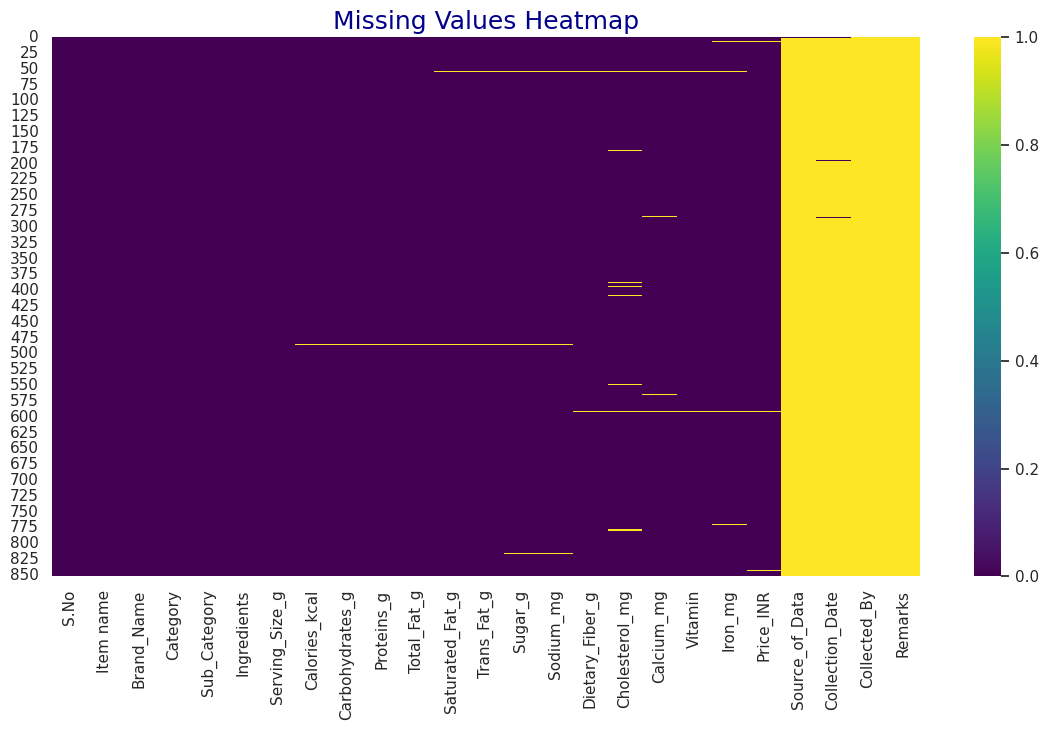

In [13]:
plt.figure(figsize=(14,7))
sns.heatmap(df.isnull(),
            cmap="viridis",
            cbar=True)

plt.title("Missing Values Heatmap",
          fontsize=18,
          color="darkblue")

plt.show()

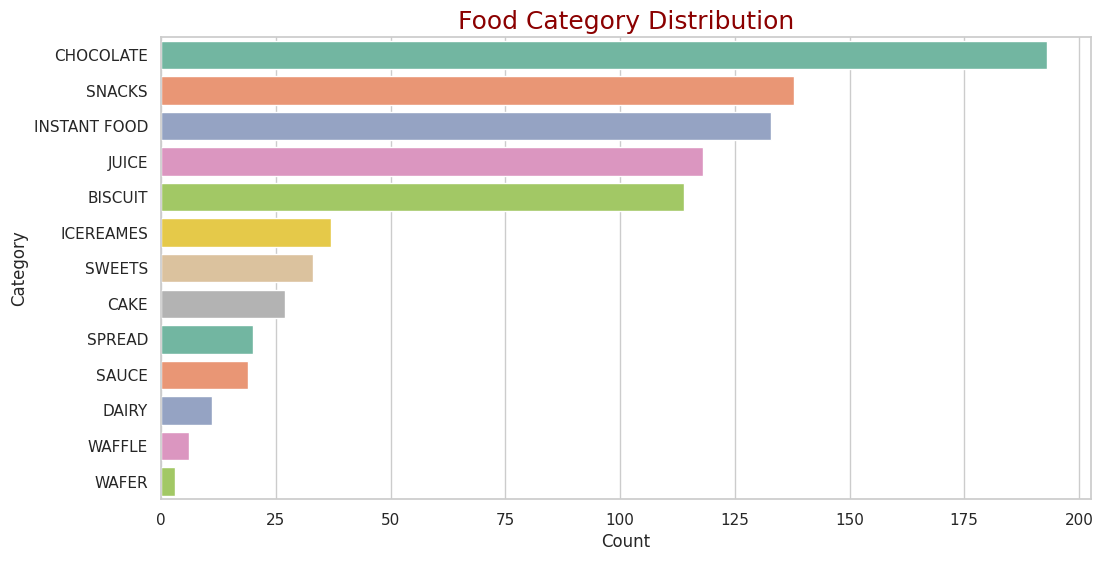

In [14]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    y='Category',
    palette="Set2",
    order=df['Category'].value_counts().index)

plt.title("Food Category Distribution",
          fontsize=18,
          color="darkred")

plt.xlabel("Count")
plt.ylabel("Category")

plt.show()

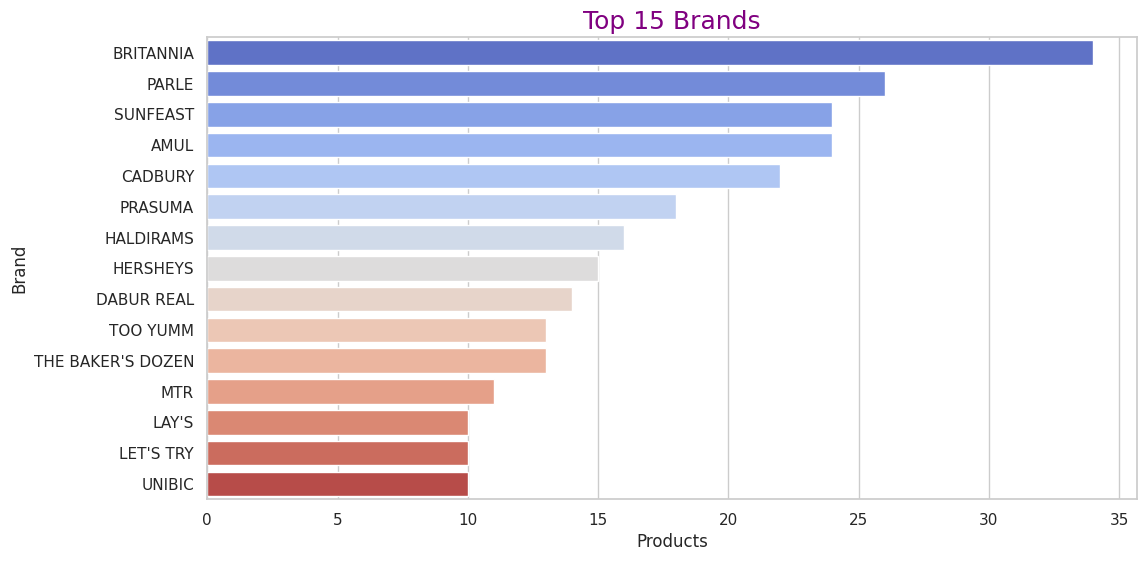

In [15]:
top_brand=df['Brand_Name'].value_counts().head(15)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_brand.values,
    y=top_brand.index,
    palette="coolwarm")

plt.title("Top 15 Brands",
          fontsize=18,
          color="purple")

plt.xlabel("Products")
plt.ylabel("Brand")

plt.show()

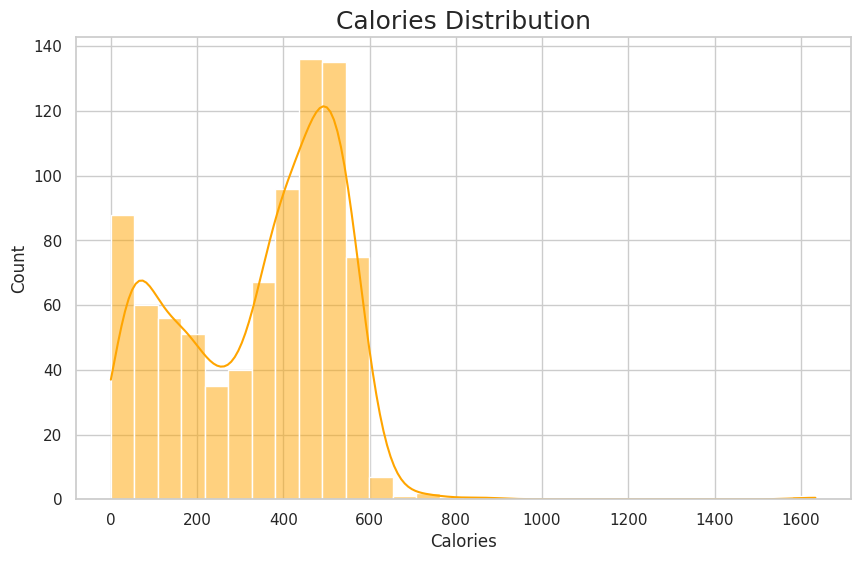

In [16]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['Calories_kcal'],
    bins=30,
    kde=True,
    color="orange")

plt.title("Calories Distribution",
          fontsize=18)

plt.xlabel("Calories")

plt.show()

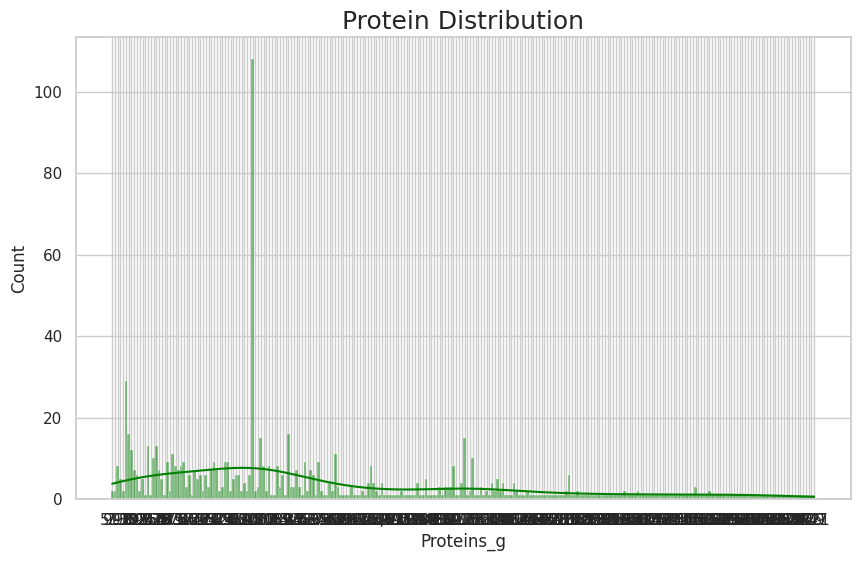

In [17]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['Proteins_g'],
    bins=25,
    color="green",
    kde=True)

plt.title("Protein Distribution",
          fontsize=18)

plt.show()

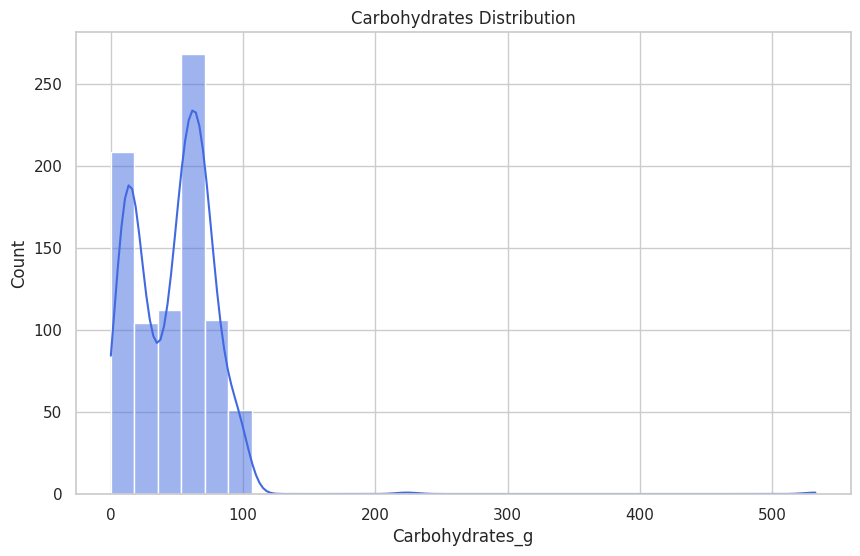

In [18]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['Carbohydrates_g'],
    bins=30,
    color="royalblue",
    kde=True)

plt.title("Carbohydrates Distribution")

plt.show()

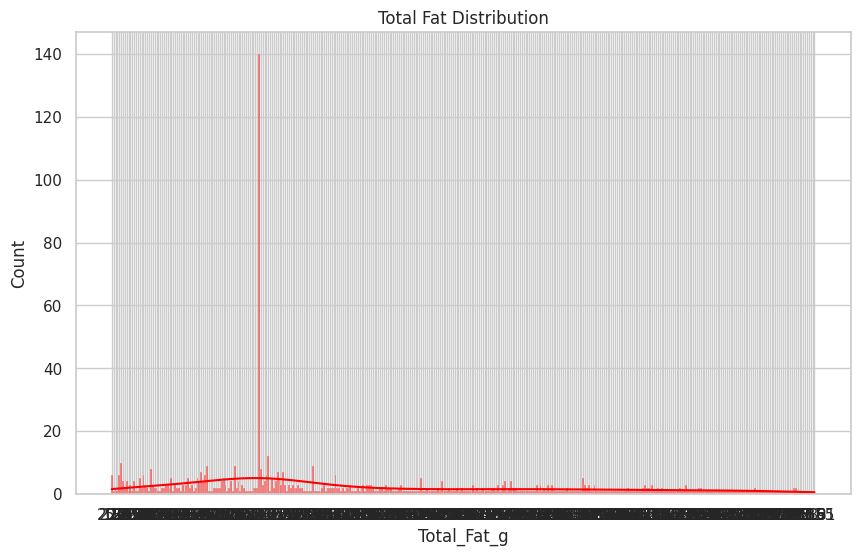

In [19]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['Total_Fat_g'],
    bins=30,
    color="red",
    kde=True)

plt.title("Total Fat Distribution")

plt.show()

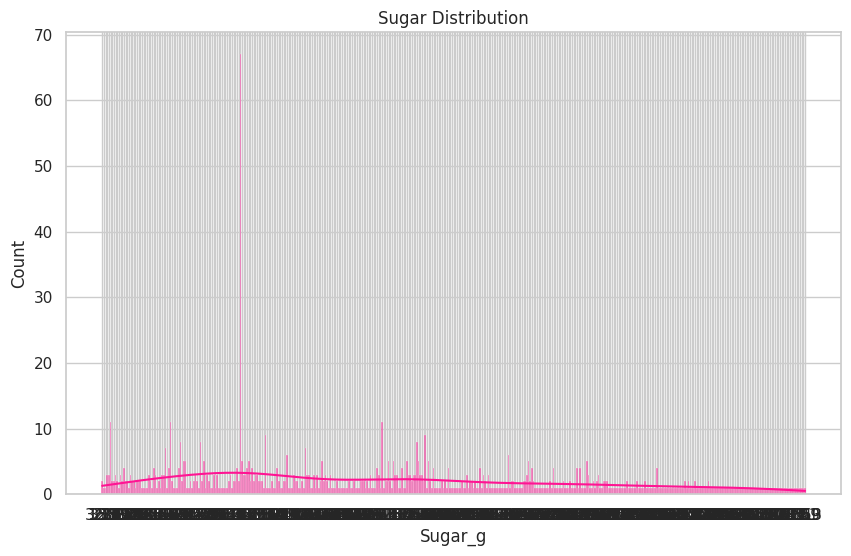

In [20]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['Sugar_g'],
    bins=30,
    color="deeppink",
    kde=True)

plt.title("Sugar Distribution")

plt.show()

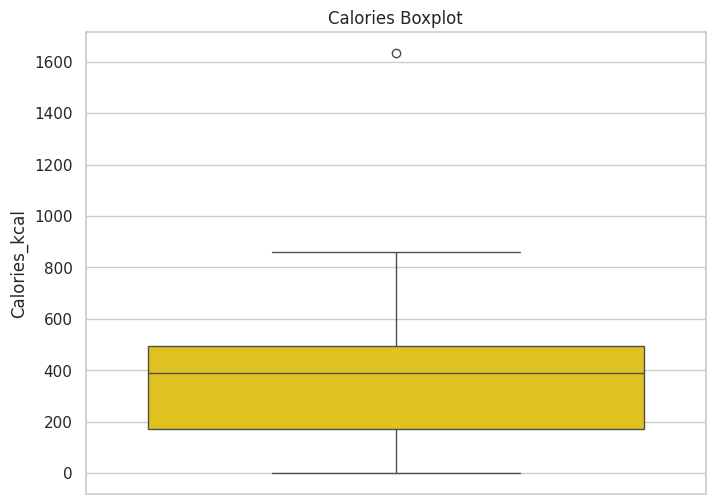

In [21]:
plt.figure(figsize=(8,6))

sns.boxplot(
    y=df['Calories_kcal'],
    color="gold")

plt.title("Calories Boxplot")

plt.show()

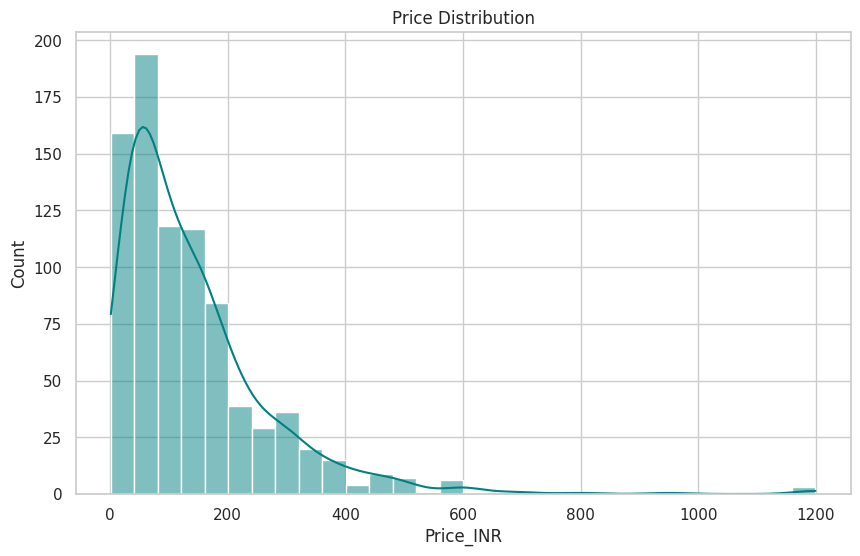

In [22]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['Price_INR'],
    bins=30,
    color="teal",
    kde=True)

plt.title("Price Distribution")

plt.show()

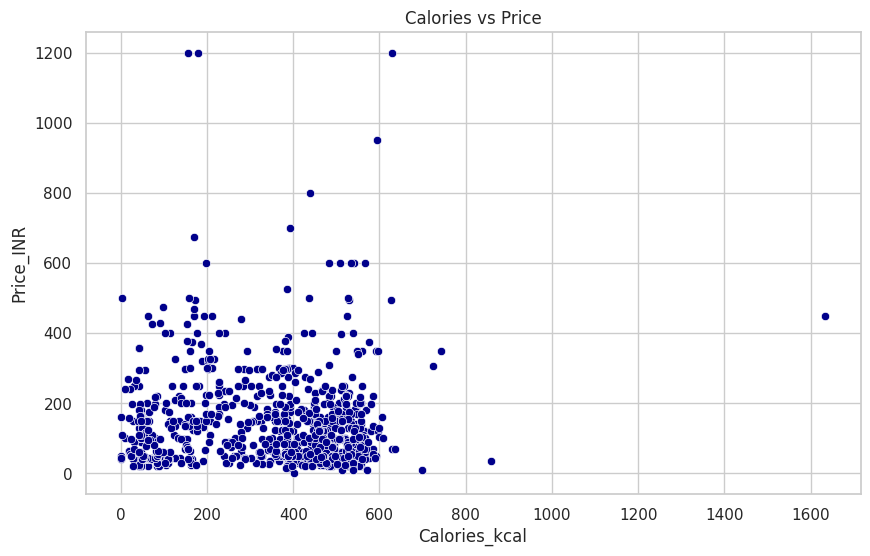

In [23]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Calories_kcal",
    y="Price_INR",
    color="darkblue")

plt.title("Calories vs Price")

plt.show()

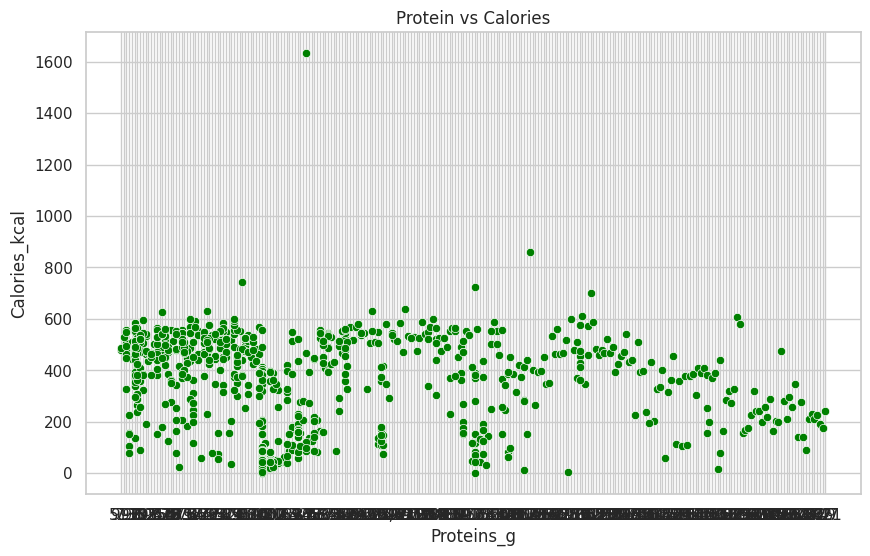

In [24]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Proteins_g",
    y="Calories_kcal",
    color="green")

plt.title("Protein vs Calories")

plt.show()

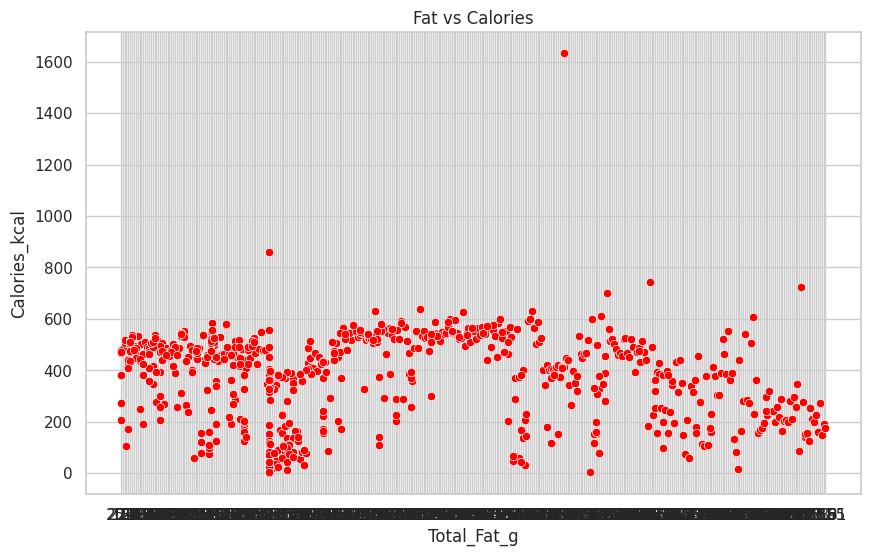

In [25]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Total_Fat_g",
    y="Calories_kcal",
    color="red")

plt.title("Fat vs Calories")

plt.show()

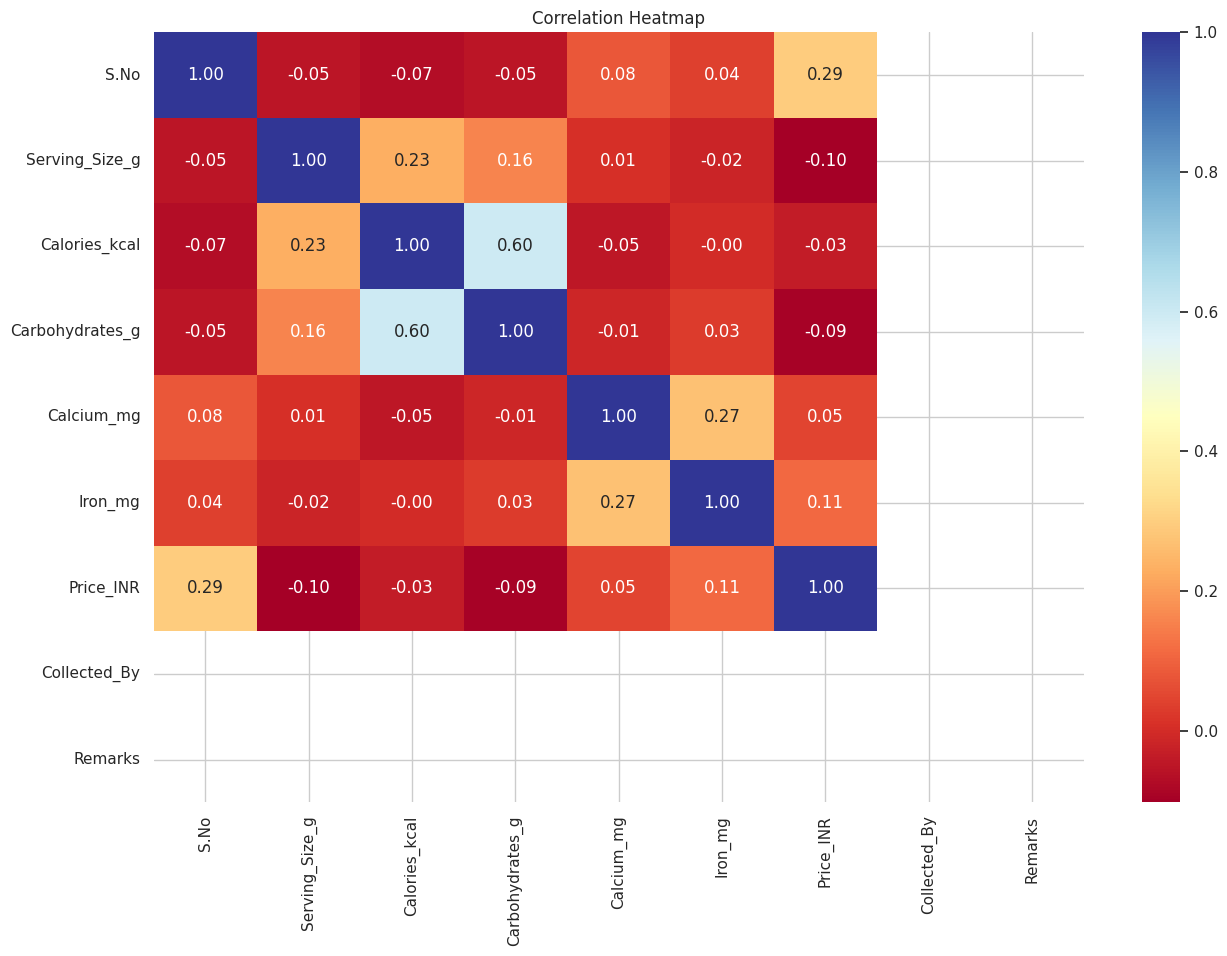

In [26]:
numeric=df.select_dtypes(include=np.number)

plt.figure(figsize=(15,10))

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap="RdYlBu",
    fmt=".2f")

plt.title("Correlation Heatmap")

plt.show()

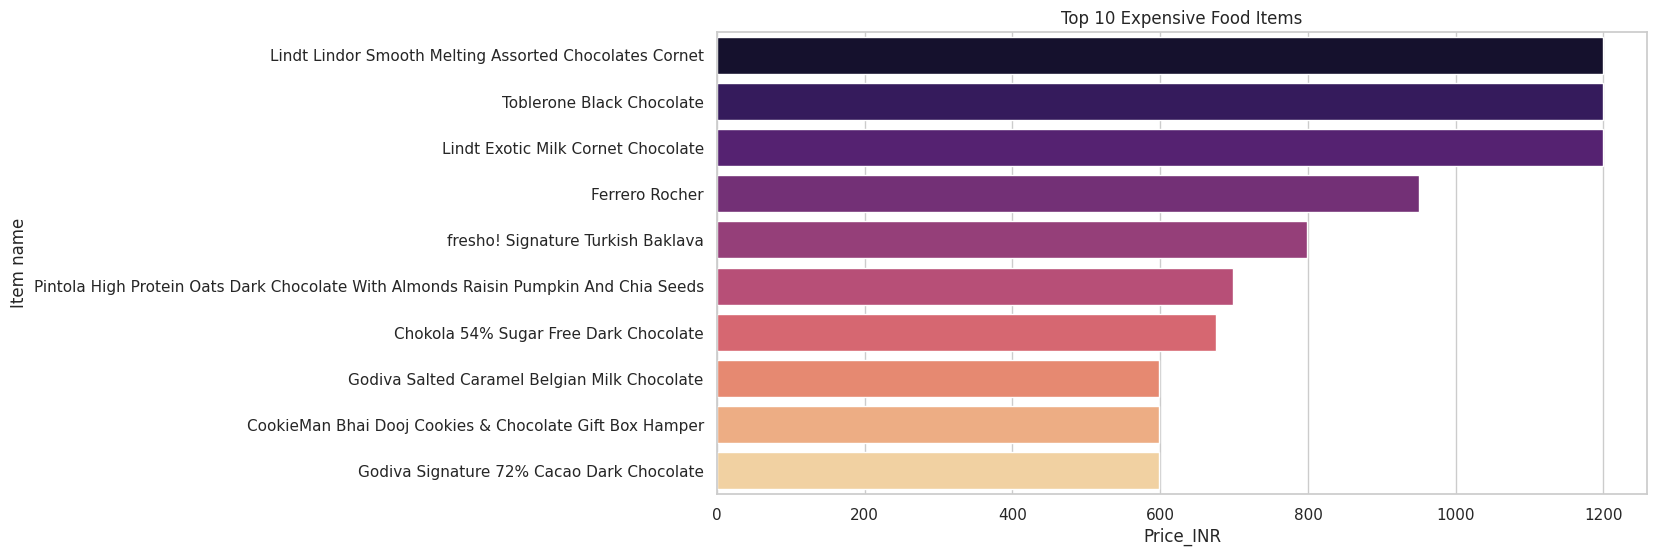

In [27]:
top=df.sort_values(
    by="Price_INR",
    ascending=False).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top,
    x="Price_INR",
    y="Item name",
    palette="magma")

plt.title("Top 10 Expensive Food Items")

plt.show()

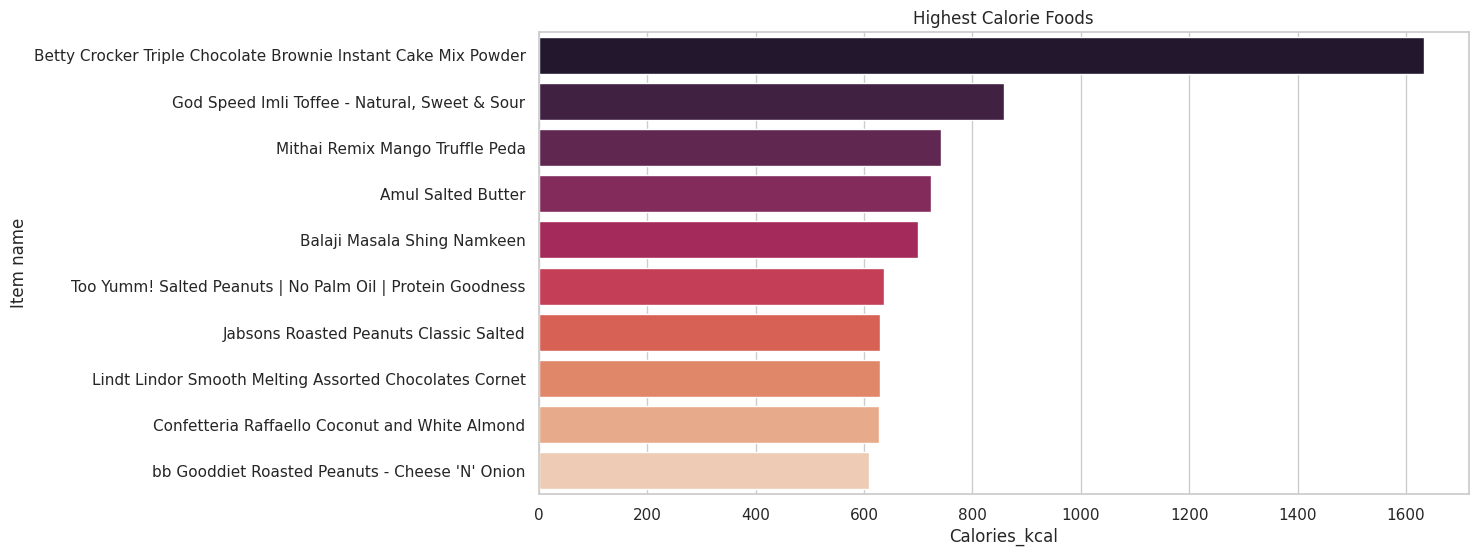

In [28]:
top=df.sort_values(
    by="Calories_kcal",
    ascending=False).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top,
    x="Calories_kcal",
    y="Item name",
    palette="rocket")

plt.title("Highest Calorie Foods")

plt.show()

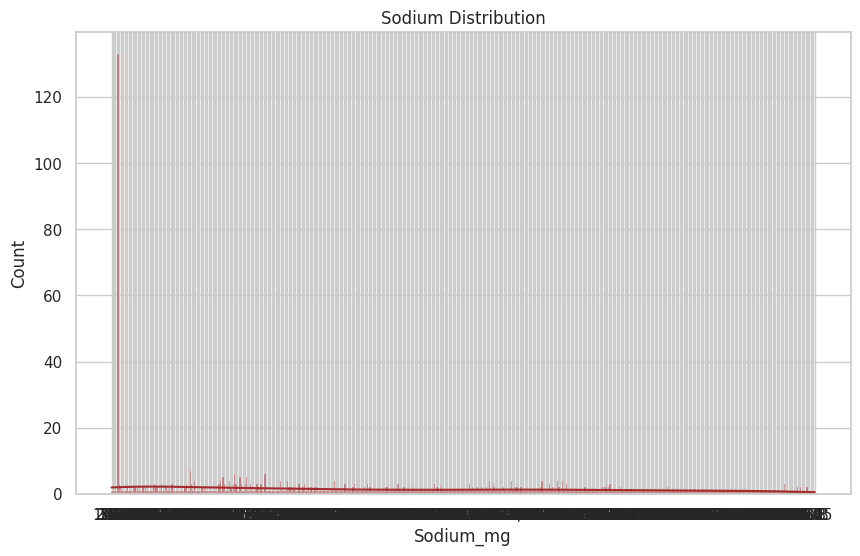

In [29]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["Sodium_mg"],
    color="brown",
    kde=True)

plt.title("Sodium Distribution")

plt.show()

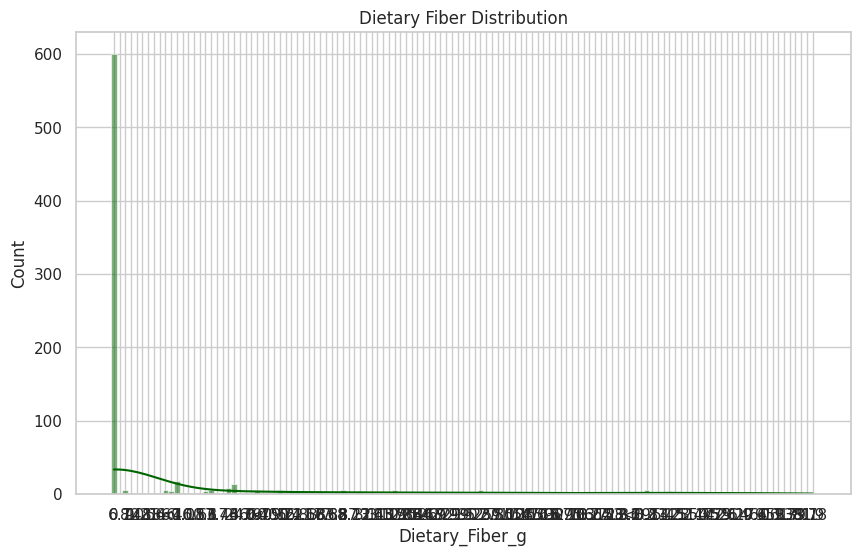

In [30]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["Dietary_Fiber_g"],
    color="darkgreen",
    kde=True)

plt.title("Dietary Fiber Distribution")

plt.show()

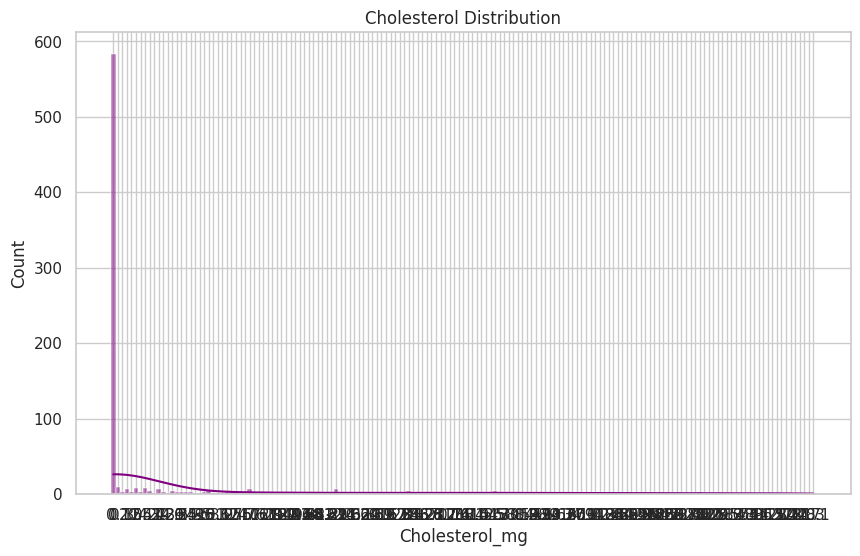

In [31]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["Cholesterol_mg"],
    color="purple",
    kde=True)

plt.title("Cholesterol Distribution")

plt.show()

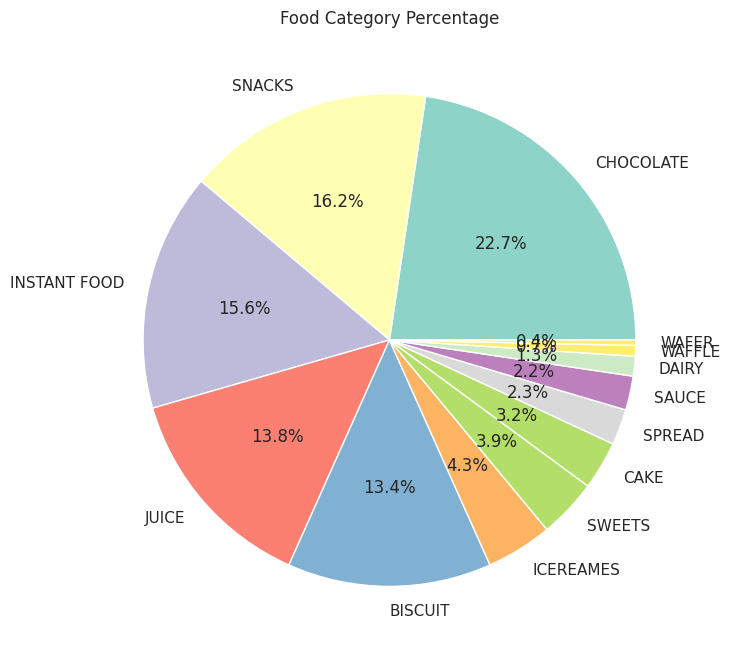

In [32]:
plt.figure(figsize=(8,8))

df["Category"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    cmap="Set3")

plt.title("Food Category Percentage")

plt.ylabel("")

plt.show()

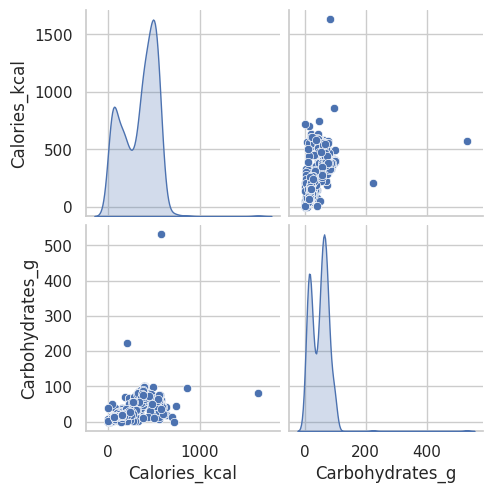

In [33]:
sns.pairplot(df[[
'Calories_kcal',
'Carbohydrates_g',
'Proteins_g',
'Total_Fat_g',
'Sugar_g'
]],
diag_kind="kde")

plt.show()

In [34]:
fig = px.scatter(
    df,
    x="Calories_kcal",
    y="Price_INR",
    color="Category",
    hover_name="Item name",
    title="Interactive Calories vs Price")

fig.show()

In [35]:
brand=df['Brand_Name'].value_counts().head(15)

fig=px.bar(
    x=brand.index,
    y=brand.values,
    color=brand.values,
    title="Top Brands",
    labels={"x":"Brand","y":"Count"})

fig.show()

In [36]:
fig=px.treemap(
    df,
    path=['Category','Brand_Name'],
    values='Price_INR',
    color='Calories_kcal')

fig.show()

## Feature engineering

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Machine Learning Algorithms

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier


In [38]:
drop_columns = [
    'S.No',
    'Item name',
    'Ingredients',
    'Source_of_Data',
    'Collection_Date',
    'Collected_By',
    'Remarks'
]

df = df.drop(columns=drop_columns)

In [39]:
# Numerical columns

num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Categorical columns

cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

In [40]:
le = LabelEncoder()

cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print(df.head())

   Brand_Name  Category  Sub_Category  Serving_Size_g  Calories_kcal  \
0         190         0            53           100.0          479.0   
1          36         0            68           100.0          483.0   
2         223         0            37           100.0          507.0   
3         223         0            53            20.0          105.0   
4         223         0            58           108.0          445.0   

   Carbohydrates_g  Proteins_g  Total_Fat_g  Saturated_Fat_g  Trans_Fat_g  \
0             73.4         175           95              270            0   
1             68.0         247          132               43            0   
2             61.1         207          183               76           11   
3             12.6          30          319              179            4   
4             77.4         245           33              224            8   

   Sugar_g  Sodium_mg  Dietary_Fiber_g  Cholesterol_mg  Calcium_mg  Vitamin  \
0      211         42    

In [41]:
X = df.drop("Category", axis=1)

y = df["Category"]

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Shape :", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape : (681, 17)
Testing Shape : (171, 17)


In [43]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [44]:
models = {

    "Logistic Regression":
        LogisticRegression(max_iter=500),

    "Decision Tree":
        DecisionTreeClassifier(random_state=42),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            random_state=42),

    "Extra Trees":
        ExtraTreesClassifier(
            n_estimators=200,
            random_state=42),

    "KNN":
        KNeighborsClassifier(),

    "Gaussian Naive Bayes":
        GaussianNB(),

    "Support Vector Machine":
        SVC(),

    "AdaBoost":
        AdaBoostClassifier(random_state=42),

    "Gradient Boosting":
        GradientBoostingClassifier(random_state=42),

    "XGBoost":
        XGBClassifier(
            eval_metric="mlogloss",
            random_state=42),

    "LightGBM":
        LGBMClassifier(random_state=42),

    "CatBoost":
        CatBoostClassifier(
            verbose=0,
            random_state=42)

}

In [45]:
results = []

for name, model in models.items():

    print("="*70)
    print(name)

    model.fit(X_train, y_train)

    prediction = model.predict(X_test)

    accuracy = accuracy_score(y_test, prediction)

    precision = precision_score(
        y_test,
        prediction,
        average="weighted"
    )

    recall = recall_score(
        y_test,
        prediction,
        average="weighted"
    )

    f1 = f1_score(
        y_test,
        prediction,
        average="weighted"
    )

    print("Accuracy : {:.2f}%".format(accuracy*100))
    print("Precision :", precision)
    print("Recall :", recall)
    print("F1 Score :", f1)

    print("\nConfusion Matrix")

    print(confusion_matrix(y_test, prediction))

    print("\nClassification Report")

    print(classification_report(y_test, prediction))

    results.append([
        name,
        accuracy*100,
        precision,
        recall,
        f1
    ])

Logistic Regression
Accuracy : 54.39%
Precision : 0.5497786119131148
Recall : 0.543859649122807
F1 Score : 0.5335109774783453

Confusion Matrix
[[14  0  4  0  0  0  1  0  3  0  1  0]
 [ 2  1  1  0  1  0  0  0  0  0  0  0]
 [ 6  0 24  0  2  4  0  0  2  0  1  0]
 [ 0  0  0  0  1  0  1  0  0  0  0  0]
 [ 0  0  0  0  3  0  2  0  0  0  2  0]
 [ 2  1  0  1  2 12  2  0  7  0  0  0]
 [ 0  1  0  0  1  3 19  0  0  0  0  0]
 [ 0  0  0  0  0  0  3  1  0  0  0  0]
 [ 3  0  3  0  0  5  0  0 17  0  0  0]
 [ 0  0  2  0  0  0  0  0  1  1  0  0]
 [ 0  0  3  0  0  2  0  0  1  0  1  0]
 [ 0  0  0  0  0  0  0  0  1  0  0  0]]

Classification Report
              precision    recall  f1-score   support

           0       0.52      0.61      0.56        23
           1       0.33      0.20      0.25         5
           2       0.65      0.62      0.63        39
           3       0.00      0.00      0.00         2
           4       0.30      0.43      0.35         7
           5       0.46      0.44      

In [46]:
results = pd.DataFrame(
    results,
    columns=[
        "Algorithm",
        "Accuracy (%)",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

results = results.sort_values(
    by="Accuracy (%)",
    ascending=False)

print(results)

                 Algorithm  Accuracy (%)  Precision    Recall  F1 Score
10                LightGBM     85.964912   0.844072  0.859649  0.849608
11                CatBoost     84.795322   0.840692  0.847953  0.840189
3              Extra Trees     84.210526   0.831278  0.842105  0.828295
2            Random Forest     83.625731   0.822786  0.836257  0.823870
9                  XGBoost     83.625731   0.849927  0.836257  0.838247
8        Gradient Boosting     83.040936   0.825530  0.830409  0.825754
1            Decision Tree     73.099415   0.741624  0.730994  0.725810
6   Support Vector Machine     64.327485   0.620760  0.643275  0.609901
7                 AdaBoost     60.233918   0.564284  0.602339  0.569916
4                      KNN     59.649123   0.556815  0.596491  0.566661
0      Logistic Regression     54.385965   0.549779  0.543860  0.533511
5     Gaussian Naive Bayes     15.204678   0.448140  0.152047  0.167808


In [47]:
print("="*70)

print("Best Performing Model")

print(results.head(1))

Best Performing Model
   Algorithm  Accuracy (%)  Precision    Recall  F1 Score
10  LightGBM     85.964912   0.844072  0.859649  0.849608


## Thank you...pls upvote!!!!!!!!!!!!!